<a href="https://colab.research.google.com/github/uppupushpa/practice/blob/main/Presentation_Dasboard_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 📊 Presentation Evaluation Dashboard

### AI & ML Data Analysis Report

**Tools Used:**
- Python
- Pandas
- Matplotlib
- Google Colab

**Objective:**
Analyze the Presentation Evaluation Dataset by cleaning the data, calculating Total Marks, identifying top-performing students, and creating a dashboard with meaningful visualizations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
upoaded=files.upload()

Saving Copy of Presentation-TASK - Sheet1.csv to Copy of Presentation-TASK - Sheet1.csv


In [ ]:
df=pd.read_csv("Copy of Presentation-TASK - Sheet1.csv")
df.head()

,UID,Participant Name,Unnamed: 2,Project Name,Technical knowledge,Communication,Attrire,Marks
0,NaN,NaN,Group No,NaN,10,10.0,5.0,NaN
1,T160600201,Gayathri Munasu,3,"types of Data visuals,application",6,6.0,3.0,NaN
2,T160600202,Namratha Bajjuri,4,Comparision of t-SNE,6,6.0,4.0,NaN
3,T160600203,Nikitha Sambangi,NaN,NaN,NaN,NaN,NaN,NaN
4,T160600204,Akhil Reddy Komireddy,3,KNN,6,7.0,3.0,NaN


In [ ]:
print("Shape of Dataset:",df.shape)
print("\nColumns")
print(df.columns)

Shape of Dataset: (85, 8)

Columns
Index(['UID', 'Participant Name', 'Unnamed: 2', 'Project Name',
       'Technical knowledge', 'Communication', 'Attrire', 'Marks'],
      dtype='object')


In [ ]:
df.rename(columns={"Unnamed: 2":"Group No"}, inplace=True)
df=df.iloc[1:]
df=df.dropna(subset=[
    "Technical knowledge",
    "Communication",
    "Attrire"
])
df["Technical knowledge"]=pd.to_numeric(df["Technical knowledge"])
df["Communication"]=pd.to_numeric(df["Communication"])
df["Attrire"]=pd.to_numeric(df["Attrire"])
df["Marks"]=(
    df["Technical knowledge"] +
    df["Communication"] +
    df["Attrire"]
)
df.head()

,UID,Participant Name,Group No,Project Name,Technical knowledge,Communication,Attrire,Marks
1,T160600201,Gayathri Munasu,3,"types of Data visuals,application",6,6.0,3.0,15.0
2,T160600202,Namratha Bajjuri,4,Comparision of t-SNE,6,6.0,4.0,16.0
4,T160600204,Akhil Reddy Komireddy,3,KNN,6,7.0,3.0,16.0
5,T160600205,CHARAN KONDA,3,"Applications of SVM ,",6,7.0,3.0,16.0
6,T160600206,Md Faisal,4,Functions,6,6.0,4.0,16.0


In [ ]:
#Summary Statistics
total_students=len(df)
highest_marks=df["Marks"].max()
lowest_marks=df["Marks"].min()
average_marks=round(df["Marks"].mean(),2)
highest_technical=df["Technical knowledge"].max()
highest_communication=df["Communication"].max()
highest_attire=df["Attrire"].max()

print("Total students :",total_students)
print("Highest Marks :",highest_marks)
print("Lowest Marks :",lowest_marks)
print("Average Marks :",average_marks)
print("Highest Technical :",highest_technical)
print("Highest Communication :",highest_communication)
print("Highest Attire :",highest_attire)

Total students : 54
Highest Marks : 19.0
Lowest Marks : 10.0
Average Marks : 15.78
Highest Technical : 8
Highest Communication : 7.0
Highest Attire : 5.0


In [ ]:
top_total=df.nlargest(5, "Marks")
top_technical=df.nlargest(5, "Technical knowledge")
top_communication=df.nlargest(5, "Communication")
top_attire=df.nlargest(5, "Attrire")

Text(0.75, 0.93, 'Highest Technical : 8')

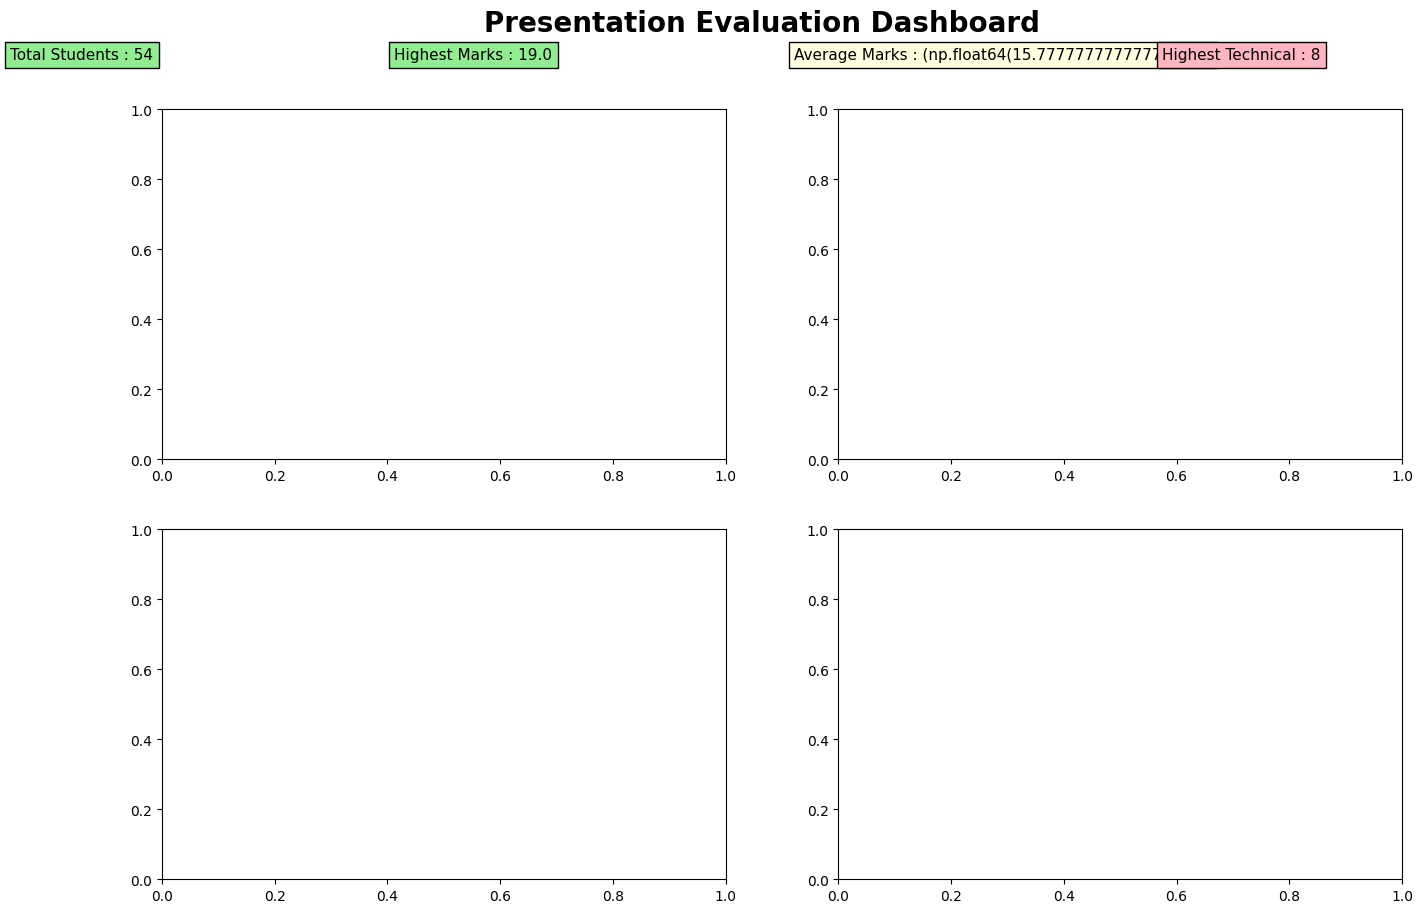

In [ ]:
import matplotlib.pyplot as plt
fig, ax=plt.subplots(2,2, figsize=(16,10))
fig.suptitle("Presentation Evaluation Dashboard", fontsize=20, fontweight='bold')

#Summary cards
fig.text(
    0.03,0.93,
    f"Total Students : {total_students}",
    fontsize=11,
    bbox=dict(facecolor="lightgreen")
)
fig.text(
    0.27,0.93,
    f"Highest Marks : {highest_marks}",
    fontsize=11,
    bbox=dict(facecolor="lightgreen")
)
fig.text(
    0.52,0.93,
    f"Average Marks : {average_marks}",
    fontsize=11,
    bbox=dict(facecolor="lightyellow")
)
fig.text(
    0.75,0.93,
    f"Highest Technical : {highest_technical}",
    fontsize=11,
    bbox=dict(facecolor="lightpink")
)

In [ ]:
top_total=df.nlargest(5, "Marks")

ax[0,0].bar(
    top_total["Participant Name"],
    top_total["Marks"],
    color="royalblue"
)
ax[0,0].set_title("Top 5 Students by Total Marks")
ax[0,0].tick_params(axis='x', rotation=25)

In [ ]:
for i,v in enumerate(top_total["Marks"]):
  ax[0,0].text(i,v+0.2,str(v),ha="center")

In [ ]:
top_technnical=df.nlargest(5, "Technical knowledge")

ax[0,1].barh(
    top_technical["Participant Name"],
    top_technical["Technical knowledge"],
    color="green"
)
ax[0,1].set_title("Top 5 Technical knowledge")

Text(0.5, 1.0, 'Top 5 Technical knowledge')

In [ ]:
for i,v in enumerate(top_technical["Technical knowledge"]):
  ax[0,1].text(v+0.1,i,str(v))

In [ ]:
top_communication=df.nlargest(5, "Communication")

ax[1,0].pie(
    top_communication["Communication"],
    labels=top_communication["Participant Name"],
    autopct="%1.1f%%",
    startangle=90
)
ax[1,0].set_title("Top 5 Communication")

Text(0.5, 1.0, 'Top 5 Communication')

In [ ]:
top_attire=df.nlargest(5, "Attrire")

ax[1,1].pie(
    top_attire["Attrire"],
    labels=top_attire["Participant Name"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)
ax[1,1].set_title("Top 5 Attire")

Text(0.5, 1.0, 'Top 5 Attire')

In [ ]:
plt.tight_layout(rect=[0,0,1,0.90])

plt.savefig(
    "Presentation_Evaluation_Dashboard.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

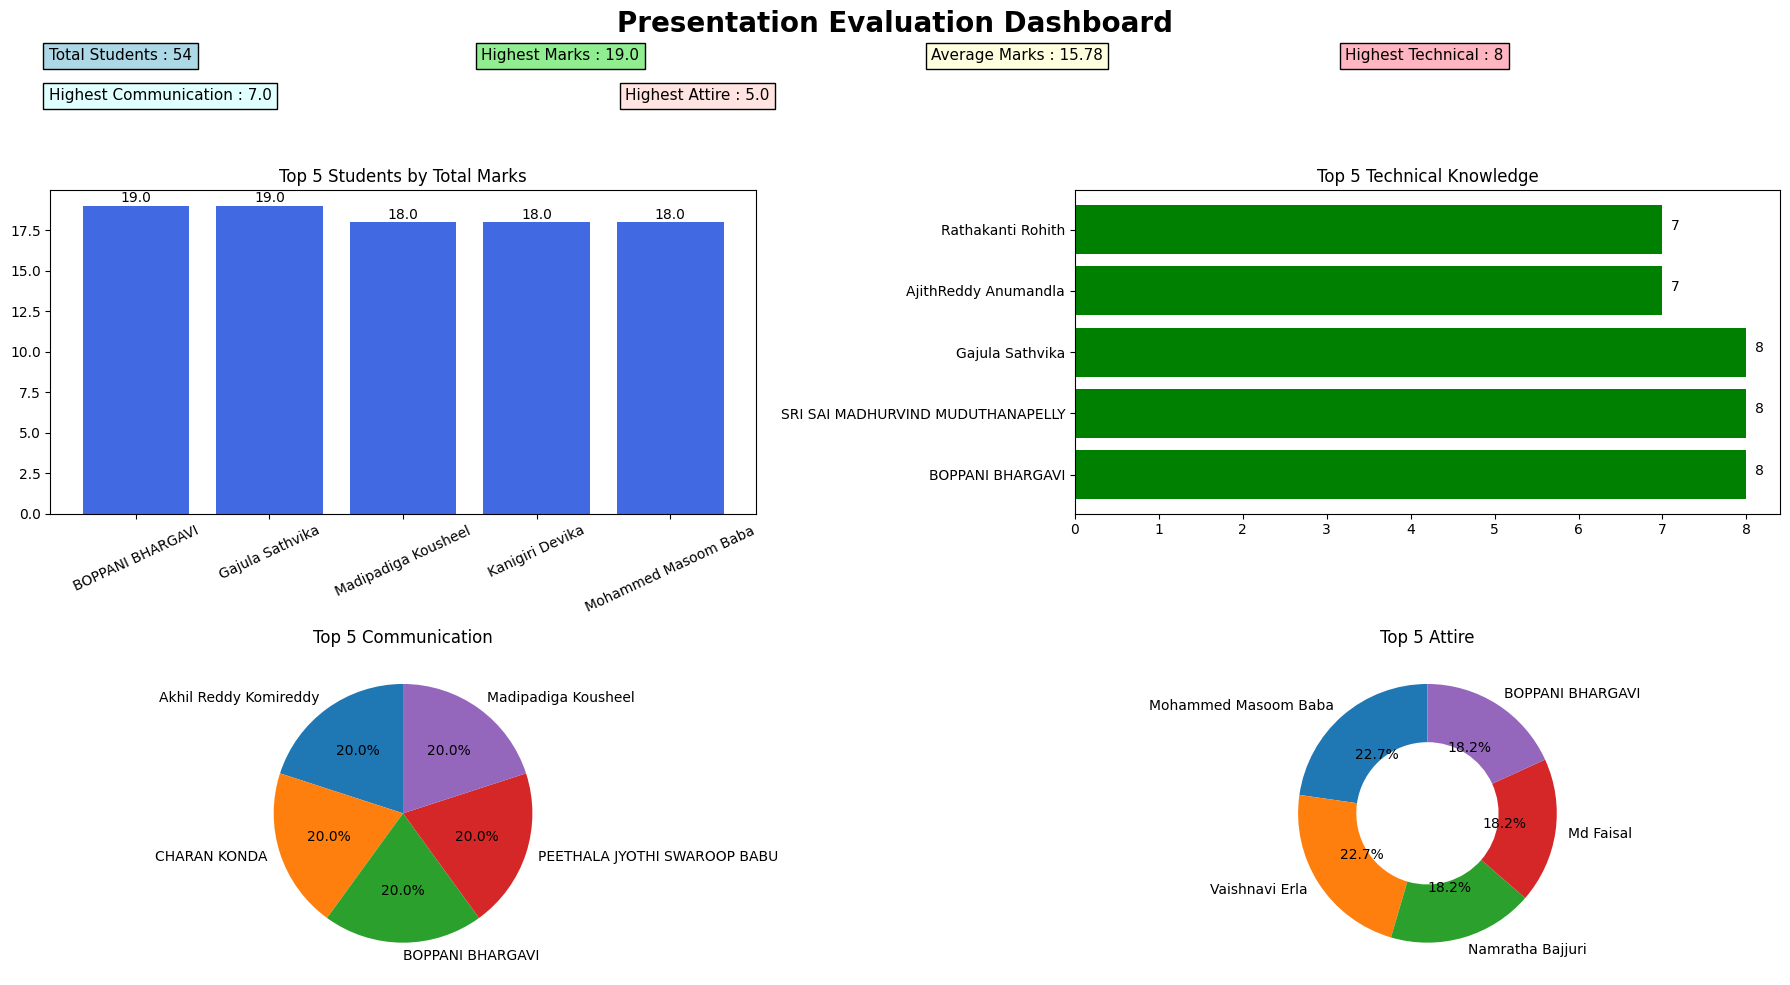

In [ ]:
import matplotlib.pyplot as plt

# Top 5 data
top_total = df.nlargest(5, "Marks")
top_technical = df.nlargest(5, "Technical knowledge")
top_communication = df.nlargest(5, "Communication")
top_attire = df.nlargest(5, "Attrire")

# Create dashboard
fig, ax = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Presentation Evaluation Dashboard", fontsize=20, fontweight="bold")

fig.text(
  0.03,0.93,
  f"Total Students : {total_students}",
  fontsize=11,
  bbox=dict(facecolor="lightblue")
)
fig.text(
  0.27,0.93,
  f"Highest Marks : {highest_marks}",
  fontsize=11,
  bbox=dict(facecolor="lightgreen")
)
fig.text(
  0.52,0.93,
  f"Average Marks : {average_marks}",
  fontsize=11,
  bbox=dict(facecolor="lightyellow")
)
fig.text(
  0.75,0.93,
  f"Highest Technical : {highest_technical}",
  fontsize=11,
  bbox=dict(facecolor="lightpink")
)
fig.text(
  0.03,0.89,
  f"Highest Communication : {highest_communication}",
  fontsize=11,
  bbox=dict(facecolor="lightcyan")
)
fig.text(
  0.35,0.89,
  f"Highest Attire : {highest_attire}",
  fontsize=11,
  bbox=dict(facecolor="mistyrose")
)

# Top Left
ax[0,0].bar(top_total["Participant Name"], top_total["Marks"], color="royalblue")
ax[0,0].set_title("Top 5 Students by Total Marks")
ax[0,0].tick_params(axis='x', rotation=25)

for i, v in enumerate(top_total["Marks"]):
  ax[0,0].text(i, v+0.2, str(v), ha="center")

# Top Right
ax[0,1].barh(top_technical["Participant Name"],
             top_technical["Technical knowledge"],
             color="green")
ax[0,1].set_title("Top 5 Technical Knowledge")

for i, v in enumerate(top_technical["Technical knowledge"]):
  ax[0,1].text(v+0.1, i, str(v))

# Bottom Left
ax[1,0].pie(
    top_communication["Communication"],
    labels=top_communication["Participant Name"],
    autopct="%1.1f%%",
    startangle=90
)
ax[1,0].set_title("Top 5 Communication")

# Bottom Right
ax[1,1].pie(
    top_attire["Attrire"],
    labels=top_attire["Participant Name"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)
ax[1,1].set_title("Top 5 Attire")

plt.tight_layout(rect=[0, 0, 1, 0.88])

plt.savefig("Presentation_Evaluation_Dashboard.png", dpi=300, bbox_inches="tight")
plt.show()